Выполнила:

Касьяненко Вера (P3420)

Установка библиотек

In [ ]:
!pip -q install pywavelets chardet pyedflib

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import chardet
import pywt
import pyedflib

from datetime import datetime
from scipy.signal import butter, sosfiltfilt, welch, medfilt, filtfilt

from google.colab import files

Загрузка данных

In [ ]:
uploaded = files.upload()
file_path = next(iter(uploaded.keys()))
print("Uploaded:", file_path)

Saving ECG-no-filter.txt to ECG-no-filter (4).txt
Uploaded: ECG-no-filter (4).txt


Функции чтения ЭКГ

In [ ]:
def detect_encoding(path: str, nbytes=200_000) -> str:
    raw = open(path, "rb").read(nbytes)
    enc = chardet.detect(raw).get("encoding") or "cp1251"
    return enc

def parse_ecg_control_txt(path: str):
    enc = detect_encoding(path)
    print("Encoding:", enc)

    with open(path, "r", encoding=enc, errors="ignore") as f:
        lines = [ln.strip() for ln in f.readlines()]

    # достаем FS из шапки
    fs = None
    for i, ln in enumerate(lines):
        if re.search(r"Частота\s+дискретизации", ln, flags=re.I) and i+1 < len(lines):
            nums = re.findall(r"[-+]?\d+(?:[.,]\d+)?", lines[i+1])
            if nums:
                fs = float(nums[0].replace(",", "."))
                break

    # парсим блоки #...
    signals = {}
    cur = None
    buf = []

    def flush():
        nonlocal cur, buf
        if cur is not None and buf:
            signals[cur] = np.array(buf, dtype=float)
        buf = []

    for ln in lines:
        if ln.startswith("#"):
            flush()
            cur = ln[1:].strip()
            continue
        if cur is None:
            continue

        nums = re.findall(r"[-+]?\d+(?:[.,]\d+)?", ln)
        if nums:
            buf.extend([float(x.replace(",", ".")) for x in nums])

    flush()

    # выровнять длины
    min_len = min(len(v) for v in signals.values())
    signals = {k: v[:min_len] for k, v in signals.items()}

    return fs, signals

fs, signals = parse_ecg_control_txt(file_path)

FS = fs if fs is not None else 100.0
df_raw = pd.DataFrame(signals)
leads = list(df_raw.columns)

t = np.arange(len(df_raw)) / FS
print("FS:", FS, "Hz")
print("Leads:", leads)
print("N:", len(df_raw))
df_raw.head()


Encoding: windows-1251
FS: 100.0 Hz
Leads: ['I', 'II', 'III', 'avR', 'avL', 'avF']
N: 11898


,I,II,III,avR,avL,avF
0,124.0,637.0,513.0,-381.0,-194.0,575.0
1,-257.0,-756.0,-498.0,506.0,120.0,-627.0
2,247.0,712.0,464.0,-479.0,-108.0,588.0
3,-295.0,-828.0,-533.0,562.0,119.0,-681.0
4,66.0,602.0,535.0,-334.0,-234.0,568.0


функции фильтрации

In [ ]:
def nyquist_suppress(x):
    """
    Убирает компоненту на частоте Найквиста
    """
    b = np.array([0.5, 0.5])
    a = np.array([1.0])
    return filtfilt(b, a, x)


In [ ]:
def reflect_pad_1d(x, fs, pad_s=3.0):
    x = np.asarray(x, float)
    n = len(x)
    p = int(pad_s * fs)
    p = min(p, n-1)
    left = x[1:p+1][::-1]
    right = x[-p-1:-1][::-1]
    return np.concatenate([left, x, right]), p

def robust_baseline_median(x, fs, win_s=0.8):
    """
    Baseline как скользящая медиана
    """
    x = np.asarray(x, float)
    k = int(win_s * fs)
    if k % 2 == 0:
        k += 1
    k = max(k, 5)
    k = min(k, len(x) - (1 - len(x) % 2))
    if k < 5:
        return np.zeros_like(x)
    return medfilt(x, kernel_size=k)

def bandpass_sos(x, fs, low=0.7, high=35.0, order=4):
    nyq = fs / 2
    low_n = max(low / nyq, 1e-4)
    high_n = min(high / nyq, 0.999)
    sos = butter(order, [low_n, high_n], btype="band", output="sos")
    return sosfiltfilt(sos, x)

def wavelet_denoise(x, wavelet="db6", thr_scale=0.8):
    x = np.asarray(x, float)
    coeffs = pywt.wavedec(x, wavelet=wavelet, level=None)
    detail = coeffs[-1]
    sigma = np.median(np.abs(detail)) / 0.6745 if detail.size else 0.0
    thr = thr_scale * sigma * np.sqrt(2 * np.log(len(x)))

    out = [coeffs[0]]
    for c in coeffs[1:]:
        out.append(pywt.threshold(c, value=thr, mode="soft"))

    y = pywt.waverec(out, wavelet=wavelet)
    return y[:len(x)]

def filter_ecg_custom(x, fs, pad_s=3.0, baseline_win_s=0.8,
                      bp_low=0.7, bp_high=35.0, bp_order=4,
                      use_wavelet=False, wavelet="db6", thr_scale=0.8):
    xp, p = reflect_pad_1d(x, fs, pad_s=pad_s)
    base = np.zeros_like(xp)
    y = xp.copy()

    y = nyquist_suppress(y)
    y = bandpass_sos(y, fs, low=bp_low, high=bp_high, order=bp_order)



    if use_wavelet:
        y = wavelet_denoise(y, wavelet=wavelet, thr_scale=thr_scale)

    return y[p:-p], base[p:-p]

Запуск фильтрации

In [ ]:
PAD_S = 3.0
BASELINE_WIN_S = 1.6

BP_LOW = 0.2
BP_HIGH = 35.0
BP_ORDER = 3

USE_WAVELET = False
WAVELET = "db6"
THR_SCALE = 0.6

df_filt = pd.DataFrame(index=df_raw.index)
df_base = pd.DataFrame(index=df_raw.index)

for lead in leads:
    y, b = filter_ecg_custom(
        df_raw[lead].to_numpy(),
        FS,
        pad_s=PAD_S,
        baseline_win_s=BASELINE_WIN_S,
        bp_low=BP_LOW, bp_high=BP_HIGH, bp_order=BP_ORDER,
        use_wavelet=USE_WAVELET, wavelet=WAVELET, thr_scale=THR_SCALE
    )
    df_filt[lead] = y
    df_base[lead] = b

print("Done. Shapes:", df_filt.shape, df_base.shape)

Done. Shapes: (11898, 6) (11898, 6)


Графики для сравнения

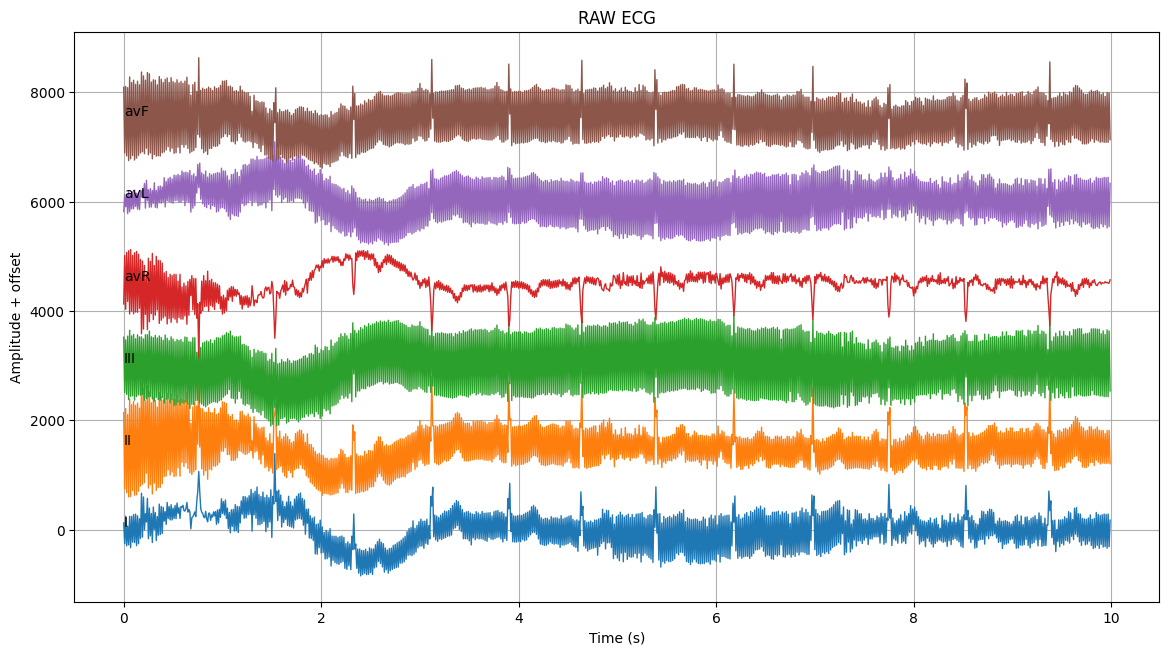

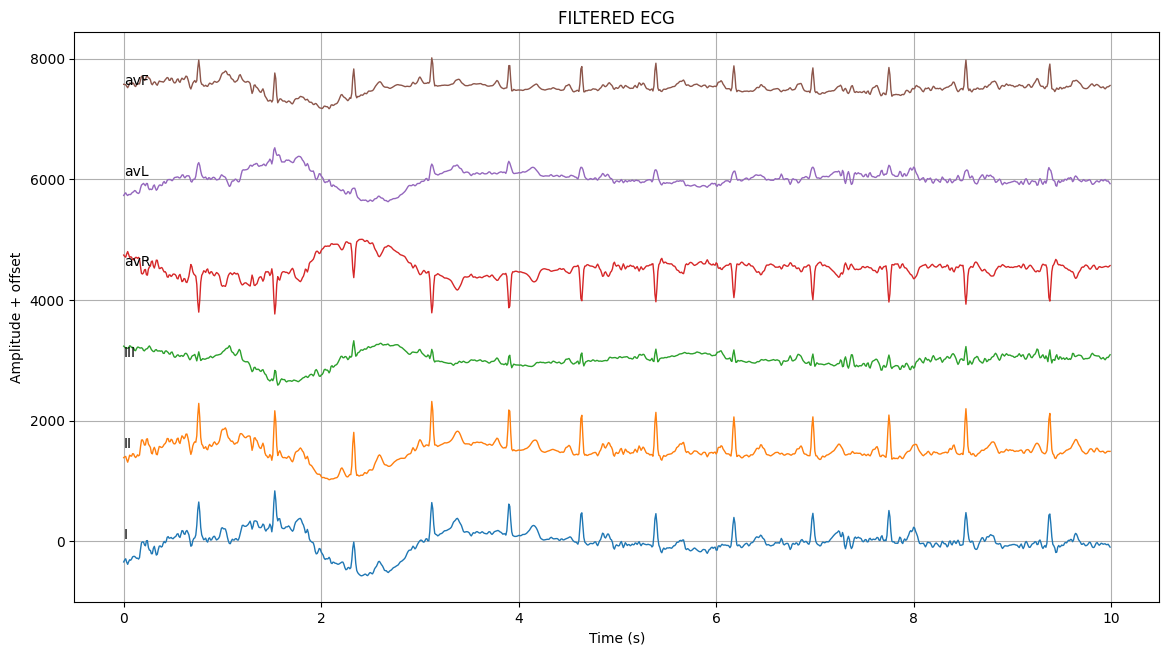

In [ ]:
def plot_multilead_fixed_offset(t, df_signals, title, fs, offset=None, start_s=0, dur_s=10):
    cols = list(df_signals.columns)
    i0 = int(start_s * fs)
    i1 = min(int((start_s + dur_s) * fs), len(df_signals))

    seg = df_signals.iloc[i0:i1][cols].to_numpy()

    if offset is None:
        scale = np.percentile(np.abs(seg), 95)
        offset = (scale * 2) if scale > 0 else 1.0

    plt.figure(figsize=(14, 0.9*len(cols)+2))
    for k, c in enumerate(cols):
        y = df_signals[c].to_numpy()[i0:i1]
        plt.plot(t[i0:i1], y + k*offset, linewidth=1)
        plt.text(t[i0], k*offset, c, va="bottom")
    plt.title(f"{title}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude + offset")
    plt.grid(True)
    plt.show()

i0, i1 = 0, int(10*FS)
scale_raw = np.percentile(np.abs(df_raw.iloc[i0:i1].to_numpy()), 95)
offset_raw = 2*scale_raw

plot_multilead_fixed_offset(t, df_raw, "RAW ECG", FS, offset=offset_raw, start_s=0, dur_s=10)
plot_multilead_fixed_offset(t, df_filt, "FILTERED ECG", FS, offset=offset_raw, start_s=0, dur_s=10)


Экспорт CSV

In [ ]:
file_name = "filtered_ecg_results.edf"

labels = list(leads)
fs = float(FS)

filtered_signals = [df_filt[l].to_numpy(dtype=np.float64) for l in labels]
n_channels = len(filtered_signals)

def phys_range(sig):
    lo = np.percentile(sig, 0.5)
    hi = np.percentile(sig, 99.5)
    m = max(abs(lo), abs(hi))
    if m < 1e-9:
        m = 1.0
    return float(-m), float(m)

with pyedflib.EdfWriter(file_name, n_channels, file_type=pyedflib.FILETYPE_EDFPLUS) as f:
    channel_info = []
    for i in range(n_channels):
        sig = filtered_signals[i]
        pmin, pmax = phys_range(sig)

        info = {
            "label": labels[i],
            "dimension": "uV",
            "sample_frequency": fs,
            "physical_min": pmin,
            "physical_max": pmax,
            "digital_min": -32768,
            "digital_max": 32767,
            "transducer": "",
            "prefilter": "nyquist_suppress + bandpass"
        }
        channel_info.append(info)

    f.setSignalHeaders(channel_info)
    f.setStartdatetime(datetime.now())
    f.writeSamples(filtered_signals)

print("Saved EDF:", file_name)
files.download(file_name)

Saved EDF: filtered_ecg_results.edf


/usr/local/lib/python3.12/dist-packages/pyedflib/edfwriter.py:133: UserWarning: Physical minimum for channel 0 (I) is -520.5217948245023, which has 18 chars, however, EDF+ can only save 8 chars, will be truncated to -520.521, some loss of precision is to be expected
  warnings.warn('Physical minimum for channel {} ({}) is {}, which has {} chars, '
/usr/local/lib/python3.12/dist-packages/pyedflib/edfwriter.py:140: UserWarning: Physical maximum for channel 0 (I) is 520.5217948245023, which has 17 chars, however, EDF+ can only save 8 chars, will be truncated to 520.5217, some loss of precision is to be expected.
  warnings.warn('Physical maximum for channel {} ({}) is {}, which has {} chars, '
/usr/local/lib/python3.12/dist-packages/pyedflib/edfwriter.py:133: UserWarning: Physical minimum for channel 1 (II) is -645.6662315879239, which has 18 chars, however, EDF+ can only save 8 chars, will be truncated to -645.666, some loss of precision is to be expected
  warnings.warn('Physical minimu

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>